# LSTM — WTI Crude Oil Next-Day Direction Classification

## Overview
A stacked LSTM reads a **30-day rolling window** of macro and price-return features and outputs a probability of the next-day price moving Up. The binary direction label (+1 / −1) is predicted by thresholding that probability at 0.5.

### Key Design Decisions
- **Sequence input**: `(batch, 30, 32)` — 30 time steps, 32 features (31 FRED-MD macro + 1 daily log-return). The LSTM can model temporal dependencies across the lookback window, unlike flat tabular models.
- **Loss**: `BCEWithLogitsLoss` — numerically stable binary cross-entropy applied to raw logits. Labels are mapped {−1 → 0, +1 → 1} internally.
- **Early stopping** monitors **validation accuracy** (patience = 25 epochs, maximise). BCE loss is tracked separately for convergence plots.
- **StandardScaler** fitted on the training fold only (applied to the flattened 3D array), preventing leakage.
- **FRED-MD t-codes** applied before any feature construction to ensure stationarity.
- **Leakage controls**: macro shifted forward one month; price lags use t−1 through t−30; target is next-day direction (uses price[t] vs price[t−1], aligned so features see only up to t−1).
- **Hyperparameter search**: 5-fold `TimeSeriesSplit` CV over a grid of hidden size, depth, dropout, and learning rate (16 configs × 5 folds = 80 fits).

In [1]:
# ============================================================
# Imports
# ============================================================
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import time
import itertools
import warnings
from abc import ABC, abstractmethod

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

warnings.filterwarnings("ignore")

# ── PyTorch ───────────────────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch {torch.__version__} | device: {DEVICE}")
except ImportError:
    raise ImportError("PyTorch is required. Run: pip install torch")

PyTorch 2.8.0 | device: cuda


## 2. Base Forecast Model

In [2]:
# ============================================================
# Abstract base class shared by all models
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs): pass

    @abstractmethod
    def predict(self, X): pass

    @abstractmethod
    def evaluate(self, X, y): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass

## 3. Evaluation Metrics

In [3]:
# ============================================================
# Classification Evaluation Metrics
# ============================================================
def evaluate_classification(y_true, y_pred, y_prob=None, label=""):
    """
    Compute and print a full classification report.
    Returns a dict of scalar metrics for downstream use.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=None, labels=[-1, 1], zero_division=0)
    rec  = recall_score(y_true, y_pred, average=None, labels=[-1, 1], zero_division=0)
    f1   = f1_score(y_true, y_pred, average=None, labels=[-1, 1], zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    if label:
        print(f"\n{'─'*50}")
        print(f"  {label}")
        print(f"{'─'*50}")
    print(classification_report(y_true, y_pred, target_names=["Down (-1)", "Up (+1)"],
                                 zero_division=0))
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  F1 (wtd): {f1_w:.4f}")

    return {
        "accuracy":    acc,
        "prec_down":   prec[0], "prec_up":   prec[1],
        "rec_down":    rec[0],  "rec_up":    rec[1],
        "f1_down":     f1[0],   "f1_up":     f1[1],
        "f1_weighted": f1_w,
        "roc_auc":     auc,
    }

## 4. FRED-MD T-Code Stationarity Transformations

| T-code | Transformation | Variables |
|--------|---------------|----------|
| 1 | Level (no change) | `S&P PE ratio`, `UMCSENTx` |
| 2 | First difference | `FEDFUNDS`, `TB3MS`, `TB6MS`, `GS1`, `GS5`, `GS10`, `AAA`, `BAA`, `TB3SMFFM`, `TB6SMFFM`, `T1YFFM`, `T5YFFM`, `T10YFFM`, `AAAFFM`, `BAAFFM` |
| 5 | Log first difference | `RPI`, `W875RX1`, `CMRMTSPLx`, `IPFPNSS`, `USWTRADE`, `USTRADE`, `BUSLOANS`, `CONSPI`, `S&P 500`, `EXSZUSx`, `EXJPUSx`, `EXUSUKx`, `EXCAUSx`, `PPICMM` |

In [4]:
# ============================================================
# FRED-MD T-Code Stationarity Transformations
# ============================================================
TCODE_MAP = {
    "RPI": 5, "W875RX1": 5, "CMRMTSPLx": 5, "IPFPNSS": 5,
    "USWTRADE": 5, "USTRADE": 5, "BUSLOANS": 5, "CONSPI": 5,
    "S&P 500": 5, "EXSZUSx": 5, "EXJPUSx": 5, "EXUSUKx": 5,
    "EXCAUSx": 5, "PPICMM": 5,
    "FEDFUNDS": 2, "TB3MS": 2, "TB6MS": 2, "GS1": 2, "GS5": 2,
    "GS10": 2, "AAA": 2, "BAA": 2, "TB3SMFFM": 2, "TB6SMFFM": 2,
    "T1YFFM": 2, "T5YFFM": 2, "T10YFFM": 2, "AAAFFM": 2, "BAAFFM": 2,
    "S&P PE ratio": 1, "UMCSENTx": 1,
}

def apply_tcodes(df: pd.DataFrame, tcode_map: dict) -> pd.DataFrame:
    """Apply FRED-MD stationarity transformations column-by-column."""
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        tc = tcode_map.get(col, 1)
        x  = df[col].astype(float)
        if tc == 1:
            out[col] = x
        elif tc == 2:
            out[col] = x.diff()
        elif tc == 5:
            out[col] = np.log(x).diff()
        else:
            out[col] = x.diff()
    return out

## 5. Data Helpers

All helpers enforce strict leakage controls:
- Macro data shifted forward one month — day `t` sees only the *previous* month's release.
- The daily log-return feature at position `i` in the window is `ret[t-window+i]`, so the last step of each window is `ret[t-1]` (yesterday's return — never today's).
- The direction target at index `t` is `sign(Price[t] − Price[t−1])`, which is only knowable after the close of day `t`. Features in the corresponding window end at `t−1`.

In [5]:
# ============================================================
# Data Helpers — leakage-safe, trading-day aligned
# ============================================================
def load_macro_monthly(path: Path, features: list) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_direction_target(price: pd.Series) -> pd.Series:
    """
    Binary next-day direction label.
      +1  if Price[t] > Price[t-1]  (Up)
      -1  if Price[t] <= Price[t-1] (Down / flat)
    """
    price = price.astype(float)
    direction = np.sign(price.diff())
    direction[direction == 0] = -1
    return direction.rename("y")

## 6. Sequence Builder

Constructs 3D sliding-window sequences `(n_samples, lookback, n_features)`:

- **Window at position i**: feature rows `[i−30, i−1]` — the 30 trading days *before* the prediction date.
- **Target at position i**: direction label on day `i` — strictly future relative to the window.
- **Features**: 31 t-code-transformed FRED-MD macro variables (forward-filled from previous month) + daily closing price = **32 features per time step**. The 30-step window delivers closing prices at t−30, t−29, …, t−1 — the 30 lagged prices required by the project spec.

In [6]:
# ============================================================
# 3D Sequence Builder for Direction Classification
# ============================================================
def build_sequences(
    macro_file: Path,
    price_file: Path,
    features: list,
    lookback: int = 30,
    train_end: str = "2014-12-31",
    val_end:   str = "2024-12-31",
):
    """
    Build leakage-safe 3D sequences for LSTM direction classification.

    Returns
    -------
    X_train, y_train, X_val, y_val, X_test, y_test : numpy arrays
    dates_train, dates_val, dates_test              : DatetimeIndex
    feat_cols                                       : list of feature names
    """
    # ── 1. Load and transform macro ──────────────────────────────────────────
    macro_m = load_macro_monthly(macro_file, features)
    macro_m = apply_tcodes(macro_m, TCODE_MAP)
    # Shift forward: day t sees previous month's release
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # ── 2. Align macro to trading days ───────────────────────────────────────
    price   = load_price(price_file)
    macro_d = macro_m.reindex(price.index, method="ffill")

    # ── 3. Build base frame ──────────────────────────────────────────────────
    # Include raw closing price as a feature. The 30-step window delivers
    # Price[t-30], Price[t-29], ..., Price[t-1] — the 30 lagged closing prices
    # required by the project spec. StandardScaler normalises prices per fold.
    base = macro_d.join(price, how="inner").dropna()

    feat_cols    = [c for c in features if c in base.columns] + ["Price"]
    feature_data = base[feat_cols].values.astype(np.float32)   # (T, F)

    # ── 4. Build direction target ─────────────────────────────────────────────
    target_series = make_direction_target(base["Price"])
    target_data   = target_series.values.astype(np.float32)
    dates         = base.index

    # ── 5. Sliding window ────────────────────────────────────────────────────
    X_list, y_list, d_list = [], [], []
    for i in range(lookback, len(feature_data)):
        if np.isfinite(target_data[i]):
            X_list.append(feature_data[i - lookback : i])   # (lookback, F)
            y_list.append(target_data[i])
            d_list.append(dates[i])

    X_all = np.array(X_list, dtype=np.float32)   # (N, lookback, F)
    y_all = np.array(y_list, dtype=np.float32)   # (N,)  values in {-1, +1}
    d_all = pd.DatetimeIndex(d_list)

    # ── 6. Chronological split ───────────────────────────────────────────────
    tr = d_all <= pd.Timestamp(train_end)
    va = (d_all > pd.Timestamp(train_end)) & (d_all <= pd.Timestamp(val_end))
    te = d_all > pd.Timestamp(val_end)

    print(f"Sequence shape: {X_all.shape}  |  features: {len(feat_cols)}")
    print(f"Train: {tr.sum()}  Val: {va.sum()}  Test: {te.sum()}")
    y_sign = y_all
    print(f"Class balance (full): Up={(y_sign==1).sum()}  Down={(y_sign==-1).sum()}")

    return (
        X_all[tr], y_all[tr],
        X_all[va], y_all[va],
        X_all[te], y_all[te],
        d_all[tr], d_all[va], d_all[te],
        feat_cols,
    )

## 7. 3D Scaler

`StandardScaler` is fitted on the training sequences only (flattened to 2D, then reshaped back to 3D). This prevents any leakage from validation or test statistics into the feature normalisation.

In [7]:
# ============================================================
# 3D Scaler — fit on train only
# ============================================================
def scale_3d(X_train, X_val=None, X_test=None):
    """
    Fit StandardScaler on training data, transform all splits.
    Operates on (N, T, F) arrays by flattening to (N*T, F).
    """
    N, T, F = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, F))

    def _tx(X):
        return scaler.transform(X.reshape(-1, F)).reshape(X.shape[0], T, F).astype(np.float32)

    out = [_tx(X_train)]
    if X_val  is not None: out.append(_tx(X_val))
    if X_test is not None: out.append(_tx(X_test))
    return tuple(out) + (scaler,)

## 8. Naive Baseline — Majority Class

Always predicts whichever direction was more common in the training set. Any model that cannot beat this has no directional forecasting skill.

In [8]:
# ============================================================
# Naive Majority-Class Baseline
# ============================================================
def naive_baseline_metrics(y_train, y_eval):
    majority = 1 if (y_train == 1).sum() >= (y_train == -1).sum() else -1
    y_pred = np.full(len(y_eval), majority)
    print(f"  Naive baseline always predicts: {'Up (+1)' if majority == 1 else 'Down (-1)'}")
    return evaluate_classification(y_eval, y_pred, y_prob=None, label="Naive Baseline")

## 9. PyTorch LSTM Network

A stacked LSTM followed by a dropout + linear head that outputs a single logit.

Key training choices:
- **`BCEWithLogitsLoss(pos_weight=...)`** — the `pos_weight` tensor (= n_Down / n_Up) upweights the minority class so the model is penalised equally for misclassifying Down vs Up. Without this, predicting Up everywhere yields near-minimum loss on a slightly Up-biased dataset.
- **Early stopping monitors validation accuracy** (not BCE loss). This is the critical fix: BCE loss is minimised at logit ≈ 0 (probability ≈ 0.5) everywhere — a degenerate "safe" solution the optimiser naturally converges to. Monitoring accuracy forces the model to actually commit to Up/Down calls.
- **Gradient clipping at 1.0** prevents exploding gradients common in LSTMs on financial time series.

In [9]:
# ============================================================
# PyTorch LSTM for Binary Direction Classification
# ============================================================
class LSTMNet(nn.Module):
    """Stacked LSTM → Dropout → Linear(1). Output is a raw logit."""
    def __init__(self, input_size: int, hidden_size: int,
                 num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)   # (batch,) logits


def _train_lstm(
    X_train, y_train, X_val, y_val,
    hidden_size, num_layers, dropout, lr,
    batch_size, epochs, patience, device,
    pos_weight=None,
):
    """
    Train one LSTM config. Returns (model, train_bce_losses, val_bal_accs).

    Labels y must be in {0.0, 1.0} (float32) for BCEWithLogitsLoss.

    Early stopping monitors VALIDATION BALANCED ACCURACY (maximise).
    Balanced accuracy = (Down recall + Up recall) / 2.  A model that
    always predicts Up scores 0.50 — the same as always predicting Down —
    so the optimiser is forced to learn *both* classes, not just the
    majority class. Overall accuracy would reward majority-class prediction
    and cause the model to collapse to predicting Up everywhere.

    pos_weight: scalar, n_neg/n_pos, passed to BCEWithLogitsLoss to
    equalise gradient contributions from Up and Down samples.
    """
    input_size = X_train.shape[2]
    model = LSTMNet(input_size, hidden_size, num_layers, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    pw = (torch.tensor([pos_weight], dtype=torch.float32).to(device)
          if pos_weight is not None else None)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size * 2, shuffle=False)

    # Convert val labels to int once for sklearn metrics
    y_val_int = y_val.astype(int)

    best_val_bal_acc = -np.inf   # maximise balanced accuracy for early stopping
    best_state       = None
    wait             = 0
    train_losses     = []   # BCE loss per epoch (for convergence plot)
    val_accs         = []   # val balanced accuracy per epoch (early stopping criterion)

    for epoch in range(1, epochs + 1):
        # ── train ──────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        train_losses.append(epoch_loss / len(train_ds))

        # ── validate — compute balanced accuracy ───────────────────────────
        model.eval()
        logits_list = []
        with torch.no_grad():
            for xb, _ in val_dl:
                logits_list.append(model(xb.to(device)).cpu().numpy())
        logits_val = np.concatenate(logits_list)
        probs_val  = torch.sigmoid(torch.tensor(logits_val)).numpy()
        preds_val  = (probs_val >= 0.5).astype(int)
        # Balanced accuracy: avg of per-class recalls — penalises Up-only prediction
        val_bal_acc = float(balanced_accuracy_score(y_val_int, preds_val))
        val_accs.append(val_bal_acc)

        # ── early stopping on balanced accuracy (maximise) ─────────────────
        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait             = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_accs

## 10. LSTM Direction Classifier

Wraps the PyTorch training loop in a `BaseForecastModel`-compatible class. Hyperparameter selection uses 5-fold `TimeSeriesSplit` CV on the training set; the best config is then retrained on all training data with the validation set controlling early stopping.

In [10]:
# ============================================================
# LSTM Direction Classifier
# ============================================================
class LSTMDirectionClassifier(BaseForecastModel):
    """
    PyTorch LSTM for binary direction classification.

    Labels convention:
        External: +1 (Up) / -1 (Down)
        Internal: 1.0 / 0.0  (BCEWithLogitsLoss requires float in [0,1])

    Early stopping uses validation BALANCED ACCURACY (not overall accuracy).
    pos_weight is passed to BCEWithLogitsLoss to balance class contributions.
    """

    def __init__(
        self,
        n_splits:    int   = 5,
        epochs:      int   = 200,
        patience:    int   = 25,
        batch_size:  int   = 128,
        device:      str   = None,
        hidden_sizes:     list = None,
        num_layers_list:  list = None,
        dropouts:         list = None,
        learning_rates:   list = None,
    ):
        super().__init__("classification")
        self.n_splits   = n_splits
        self.epochs     = epochs
        self.patience   = patience
        self.batch_size = batch_size
        self.device     = device or DEVICE

        # Hyperparameter grid (16 configs × 5 folds = 80 fits)
        self.hidden_sizes    = hidden_sizes    or [32, 64]
        self.num_layers_list = num_layers_list or [1, 2]
        self.dropouts        = dropouts        or [0.2, 0.4]
        self.learning_rates  = learning_rates  or [1e-3, 5e-4]

        self.model_        = None
        self.scaler_       = None
        self.best_params_  = None
        self.cv_results_   = []
        self.train_losses_ = []   # BCE loss per epoch (final model)
        self.val_accs_     = []   # val balanced accuracy per epoch (final model)
        self.feature_names_ = None

    # ── Label helpers ─────────────────────────────────────────────────────────
    @staticmethod
    def _to_binary(y):
        """Map {-1, +1} → {0.0, 1.0} for BCEWithLogitsLoss."""
        return ((np.asarray(y, dtype=np.float32) + 1) / 2)

    @staticmethod
    def _to_signed(y_bin):
        """Map probability/binary → {-1, +1}."""
        return np.where(np.asarray(y_bin) >= 0.5, 1, -1)

    # ── Training ──────────────────────────────────────────────────────────────
    def fit(self, X_train: np.ndarray, y_train: np.ndarray,
            X_val: np.ndarray = None, y_val: np.ndarray = None):
        """
        1. 5-fold CV grid search on training data (scale per fold, pos_weight per fold).
           Folds are ranked by balanced accuracy so the selected config learns both classes.
        2. Refit best config on full training data with val set for early stopping.
        """
        grid = list(itertools.product(
            self.hidden_sizes, self.num_layers_list,
            self.dropouts, self.learning_rates,
        ))
        print(f"\n[LSTM Direction] CV: {len(grid)} configs × {self.n_splits} folds"
              f" = {len(grid)*self.n_splits} fits")

        tscv     = TimeSeriesSplit(n_splits=self.n_splits)
        best_acc = -np.inf
        best_cfg = None

        for cfg_idx, (hs, nl, do, lr) in enumerate(grid):
            fold_accs = []
            print(f"  Config {cfg_idx+1:>2}/{len(grid)} "
                  f"hidden={hs}, layers={nl}, drop={do}, lr={lr}", end=" ")
            for tr_idx, va_idx in tscv.split(X_train):
                Xtr, Xva = X_train[tr_idx], X_train[va_idx]
                ytr, yva = y_train[tr_idx], y_train[va_idx]

                # Scale per fold — no leakage
                Xtr_s, Xva_s, _ = scale_3d(Xtr, Xva)

                # Class balance weight for this fold
                ytr_bin = self._to_binary(ytr)
                n_neg   = (ytr_bin == 0).sum()
                n_pos   = (ytr_bin == 1).sum()
                spw     = float(n_neg / n_pos) if n_pos > 0 else 1.0

                m, _, _ = _train_lstm(
                    Xtr_s, ytr_bin,
                    Xva_s, self._to_binary(yva),
                    hidden_size=hs, num_layers=nl,
                    dropout=do, lr=lr,
                    batch_size=self.batch_size,
                    epochs=self.epochs, patience=self.patience,
                    device=self.device,
                    pos_weight=spw,
                )
                m.eval()
                with torch.no_grad():
                    logits = m(torch.tensor(Xva_s).to(self.device)).cpu().numpy()
                preds = self._to_signed(torch.sigmoid(torch.tensor(logits)).numpy())
                # Rank folds by balanced accuracy (not overall accuracy)
                fold_accs.append(balanced_accuracy_score(yva, preds))
                print(".", end="", flush=True)

            mean_acc = float(np.mean(fold_accs))
            self.cv_results_.append({
                "hidden": hs, "layers": nl, "dropout": do, "lr": lr,
                "bal_accuracy": mean_acc,
            })
            print(f"  → mean bal_acc: {mean_acc:.4f}")

            if mean_acc > best_acc:
                best_acc = mean_acc
                best_cfg = (hs, nl, do, lr)

        hs, nl, do, lr = best_cfg
        self.best_params_ = {
            "hidden_size": hs, "num_layers": nl,
            "dropout": do, "learning_rate": lr,
            "cv_bal_accuracy": best_acc,
        }
        print(f"\nBest config: {self.best_params_}")

        # ── Final model — pos_weight from full training set ───────────────────
        ytr_bin = self._to_binary(y_train)
        n_neg   = (ytr_bin == 0).sum()
        n_pos   = (ytr_bin == 1).sum()
        spw     = float(n_neg / n_pos) if n_pos > 0 else 1.0

        if X_val is not None and y_val is not None:
            Xtr_s, Xva_s, scaler = scale_3d(X_train, X_val)
            yva_bin = self._to_binary(y_val)
        else:
            Xtr_s, scaler = scale_3d(X_train)[:2]
            Xva_s   = Xtr_s[-100:]
            yva_bin = ytr_bin[-100:]

        self.scaler_ = scaler

        self.model_, self.train_losses_, self.val_accs_ = _train_lstm(
            Xtr_s, ytr_bin,
            Xva_s, yva_bin,
            hidden_size=hs, num_layers=nl, dropout=do, lr=lr,
            batch_size=self.batch_size,
            epochs=self.epochs, patience=self.patience,
            device=self.device,
            pos_weight=spw,
        )
        return self

    # ── Inference ─────────────────────────────────────────────────────────────
    def _scale_input(self, X: np.ndarray) -> np.ndarray:
        N, T, F = X.shape
        return self.scaler_.transform(X.reshape(-1, F)).reshape(N, T, F).astype(np.float32)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Return P(Up) for each sample."""
        Xs = self._scale_input(X)
        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(torch.tensor(Xs).to(self.device)).cpu().numpy()
        return torch.sigmoid(torch.tensor(logits)).numpy()

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Return predicted class labels (+1 / -1)."""
        return self._to_signed(self.predict_proba(X) >= threshold)

    def tune_threshold(self, X_val: np.ndarray, y_val: np.ndarray,
                       thresholds=None) -> float:
        """Find threshold maximising balanced accuracy on validation set.

        Balanced accuracy = (Down recall + Up recall) / 2.  Using it here
        prevents the threshold search from collapsing to the majority-class
        region (which would maximise overall accuracy but ignore Down).
        """
        if thresholds is None:
            thresholds = np.linspace(0.3, 0.7, 41)
        proba = self.predict_proba(X_val)
        # Map {-1, +1} labels to {0, 1} for balanced_accuracy_score
        y_val_bin = ((np.asarray(y_val) + 1) / 2).astype(int)
        best_t, best_bal_acc = 0.5, -np.inf
        for t in thresholds:
            preds_bin = (proba >= t).astype(int)
            bal_acc = balanced_accuracy_score(y_val_bin, preds_bin)
            if bal_acc > best_bal_acc:
                best_bal_acc, best_t = bal_acc, t
        print(f"  Optimal threshold: {best_t:.3f}  (val balanced accuracy: {best_bal_acc:.4f})")
        return best_t

    # ── Evaluation ───────────────────────────────────────────────────────────
    def evaluate(self, X: np.ndarray, y: np.ndarray, label="", threshold=0.5):
        y_pred = self.predict(X, threshold=threshold)
        y_prob = self.predict_proba(X)
        return evaluate_classification(y, y_pred, y_prob, label=label)

    # ── Persistence ──────────────────────────────────────────────────────────
    def save(self, path: str):
        state = {k: v for k, v in self.__dict__.items() if k != "model_"}
        state["model_state"] = self.model_.state_dict() if self.model_ else None
        with open(path, "wb") as f:
            pickle.dump(state, f)

    def load(self, path: str):
        with open(path, "rb") as f:
            state = pickle.load(f)
        model_state = state.pop("model_state", None)
        self.__dict__.update(state)
        if model_state and self.best_params_:
            p = self.best_params_
            net = LSTMNet(
                input_size=len(self.feature_names_) if self.feature_names_ else 32,
                hidden_size=p["hidden_size"],
                num_layers=p["num_layers"],
                dropout=p["dropout"],
            ).to(self.device)
            net.load_state_dict(model_state)
            self.model_ = net

## 11. Configuration

In [11]:
# ============================================================
# Configuration
# ============================================================
MACRO_FILE = Path("../data/fred_md_2025_12.csv")
PRICE_FILE = Path("../data/price/Price.csv")

FEATURES = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]

LOOKBACK  = 30
TRAIN_END = "2014-12-31"
VAL_END   = "2024-12-31"

## 12. Training

Build 3D sequences, run 5-fold CV grid search (16 configs × 5 folds = 80 fits), fit the final model with early stopping on the validation set. All evaluation is strictly out-of-sample.

In [12]:
# ============================================================
# Build sequences and train
# ============================================================
t0 = time.time()

(X_train, y_train, X_val, y_val, X_test, y_test,
 dates_train, dates_val, dates_test, feat_cols) = build_sequences(
    MACRO_FILE, PRICE_FILE, FEATURES,
    lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END,
)

print(f"\nInput shape  : {X_train.shape}  (samples, lookback, features)")
print(f"Device       : {DEVICE}")

# ── Train ─────────────────────────────────────────────────────────────────────
model = LSTMDirectionClassifier()
model.feature_names_ = feat_cols
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# ── Default-threshold predictions ─────────────────────────────────────────────
pred_val   = model.predict(X_val)
pred_test  = model.predict(X_test)
prob_val   = model.predict_proba(X_val)
prob_test  = model.predict_proba(X_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  LSTM — CLASSIFICATION RESULTS (threshold = 0.50)")
print("="*60)
val_metrics  = model.evaluate(X_val,  y_val,  label="Validation")
test_metrics = model.evaluate(X_test, y_test, label="Test")

# ── Naive baseline ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  NAIVE MAJORITY-CLASS BASELINE")
print("="*60)
naive_val  = naive_baseline_metrics(y_train, y_val)
naive_test = naive_baseline_metrics(y_train, y_test)

# ── Threshold optimisation ────────────────────────────────────────────────────
print("\n" + "="*60)
print("  THRESHOLD OPTIMISATION (tuned on val, applied to test)")
print("="*60)
best_threshold = model.tune_threshold(X_val, y_val)
pred_val_tuned  = model.predict(X_val,  threshold=best_threshold)
pred_test_tuned = model.predict(X_test, threshold=best_threshold)
val_metrics_tuned  = model.evaluate(X_val,  y_val,  label="Validation (tuned)", threshold=best_threshold)
test_metrics_tuned = model.evaluate(X_test, y_test, label="Test (tuned)",        threshold=best_threshold)

elapsed = time.time() - t0
print(f"\nTotal training time: {elapsed/60:.1f} min")

Sequence shape: (10805, 30, 32)  |  features: 32
Train: 7954  Val: 2635  Test: 216
Class balance (full): Up=5509  Down=5296

Input shape  : (7954, 30, 32)  (samples, lookback, features)
Device       : cuda

[LSTM Direction] CV: 16 configs × 5 folds = 80 fits
  Config  1/16 hidden=32, layers=1, drop=0.2, lr=0.001 .....  → mean bal_acc: 0.5210
  Config  2/16 hidden=32, layers=1, drop=0.2, lr=0.0005 .....  → mean bal_acc: 0.5200
  Config  3/16 hidden=32, layers=1, drop=0.4, lr=0.001 .....  → mean bal_acc: 0.5194
  Config  4/16 hidden=32, layers=1, drop=0.4, lr=0.0005 .....  → mean bal_acc: 0.5132
  Config  5/16 hidden=32, layers=2, drop=0.2, lr=0.001 .....  → mean bal_acc: 0.5148
  Config  6/16 hidden=32, layers=2, drop=0.2, lr=0.0005 .....  → mean bal_acc: 0.5159
  Config  7/16 hidden=32, layers=2, drop=0.4, lr=0.001 .....  → mean bal_acc: 0.5214
  Config  8/16 hidden=32, layers=2, drop=0.4, lr=0.0005 .....  → mean bal_acc: 0.5190
  Config  9/16 hidden=64, layers=1, drop=0.2, lr=0.001 ..

## 13. Summary Table

In [13]:
# ============================================================
# Comparison Table
# ============================================================
rows = []
for split, m_def, m_tun, m_naive in [
    ("Validation", val_metrics,  val_metrics_tuned,  naive_val),
    ("Test",       test_metrics, test_metrics_tuned, naive_test),
]:
    for name, m in [("LSTM (θ=0.50)", m_def), (f"LSTM (θ={best_threshold:.2f})", m_tun), ("Naive", m_naive)]:
        rows.append({
            "Split":     split,
            "Model":     name,
            "Accuracy":  f"{m['accuracy']:.4f}",
            "Prec Down": f"{m['prec_down']:.4f}",
            "Prec Up":   f"{m['prec_up']:.4f}",
            "Rec Down":  f"{m['rec_down']:.4f}",
            "Rec Up":    f"{m['rec_up']:.4f}",
            "F1 (wtd)":  f"{m['f1_weighted']:.4f}",
            "ROC-AUC":   f"{m['roc_auc']:.4f}" if not np.isnan(m['roc_auc']) else "N/A",
        })

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nBest params : {model.best_params_}")

     Split         Model Accuracy Prec Down Prec Up Rec Down Rec Up F1 (wtd) ROC-AUC
Validation LSTM (θ=0.50)   0.5120    0.4792  0.5356   0.4274 0.5871   0.5092  0.4983
Validation LSTM (θ=0.38)   0.5264    0.4926  0.5351   0.2153 0.8029   0.4810  0.4983
Validation         Naive   0.5294    0.0000  0.5294   0.0000 1.0000   0.3665     N/A
      Test LSTM (θ=0.50)   0.5046    0.5217  0.5000   0.2202 0.7944   0.4603  0.4765
      Test LSTM (θ=0.38)   0.4815    0.4286  0.4872   0.0826 0.8879   0.3815  0.4765
      Test         Naive   0.4954    0.0000  0.4954   0.0000 1.0000   0.3282     N/A

Best params : {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.4, 'learning_rate': 0.001, 'cv_bal_accuracy': 0.5218876019516122}


---
# Visualizations

## 14. Plot Setup

In [14]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C = {
    'up':    '#2a9d8f', 'down':   '#e76f51',
    'model': '#57068c', 'naive':  '#a8a8a8',
    'train': '#264653', 'accent': '#e63946',
}
print("Plot setup complete.")

Plot setup complete.


## 15. Training Convergence

Left axis: training BCE loss per epoch (decreasing = model is learning weights).
Right axis: validation **balanced accuracy** per epoch — (Down recall + Up recall) / 2 — used as the early stopping criterion. A model predicting only Up scores 0.50; the model must improve recall on both classes to exceed this baseline.
The vertical dashed line marks the best epoch — the weights saved for inference.

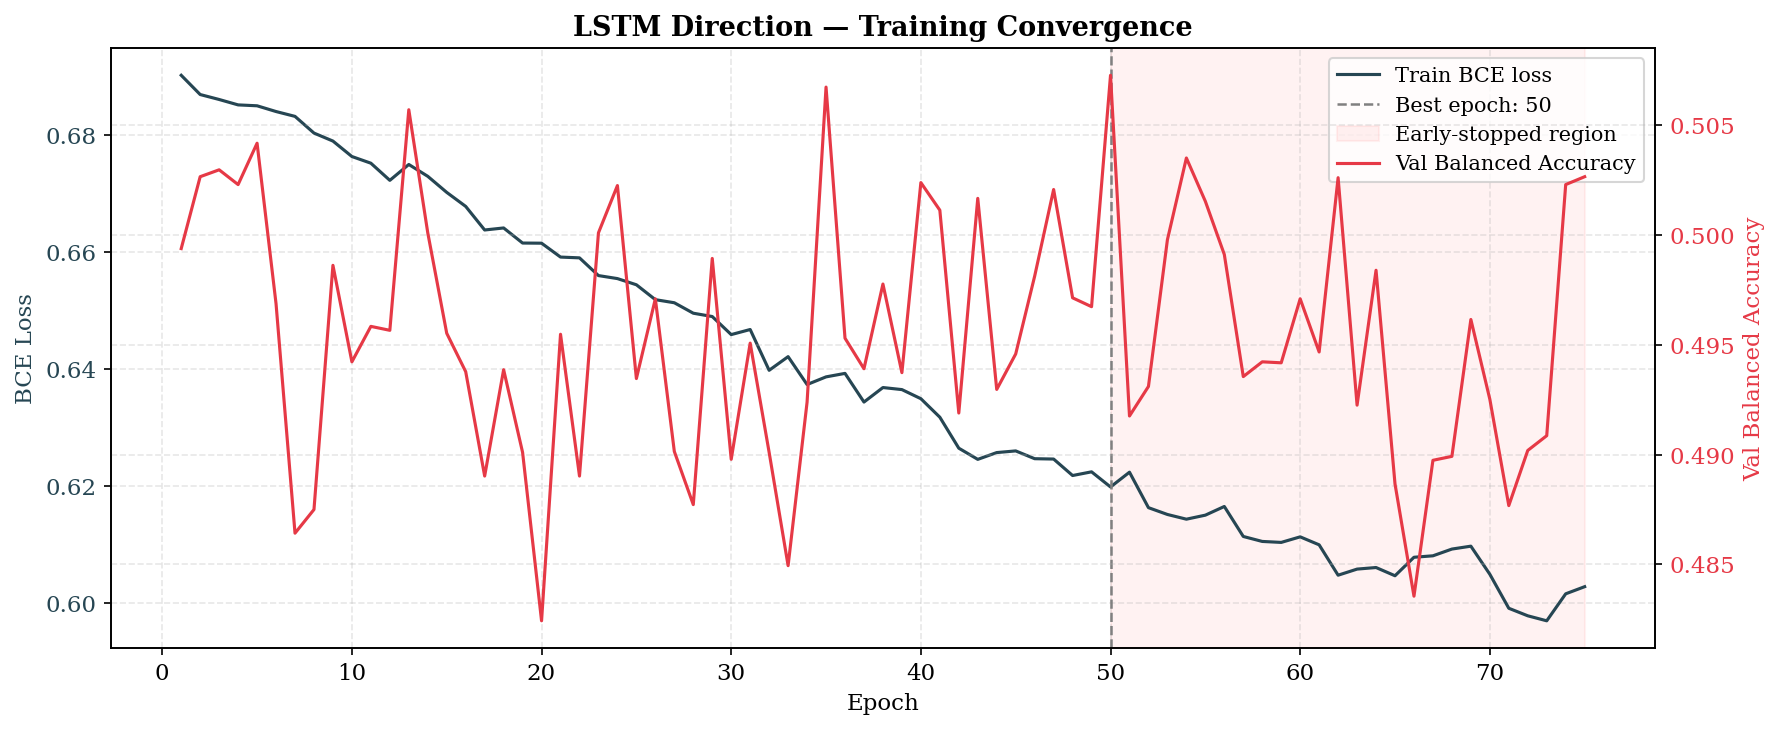

Final model ran 75 epochs; best val balanced acc 0.5073 at epoch 50.


In [15]:
# ============================================================
# Training Convergence — BCE Loss & Val Balanced Accuracy
# ============================================================
train_l   = model.train_losses_   # BCE loss per epoch
val_a     = model.val_accs_        # val balanced accuracy per epoch
epochs_ran = np.arange(1, len(train_l) + 1)
best_ep   = int(np.argmax(val_a)) + 1   # epoch with highest val balanced accuracy

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis — train BCE loss
ax1.plot(epochs_ran, train_l, color=C["train"], lw=1.5,
         label="Train BCE loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss", color=C["train"])
ax1.tick_params(axis="y", labelcolor=C["train"])

# Right axis — val balanced accuracy
ax2 = ax1.twinx()
ax2.plot(epochs_ran, val_a, color=C["accent"], lw=1.5,
         label="Val Balanced Accuracy")
ax2.set_ylabel("Val Balanced Accuracy", color=C["accent"])
ax2.tick_params(axis="y", labelcolor=C["accent"])

# Best-epoch marker (shared x)
ax1.axvline(best_ep, color="gray", lw=1.2, ls="--",
            label=f"Best epoch: {best_ep}")
ax1.axvspan(best_ep, epochs_ran[-1], alpha=0.05, color="red",
            label="Early-stopped region")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("LSTM Direction — Training Convergence", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Final model ran {len(train_l)} epochs; best val balanced acc {max(val_a):.4f} at epoch {best_ep}.")

## 16. Confusion Matrices

Side-by-side heatmaps for validation and test, using the tuned threshold.

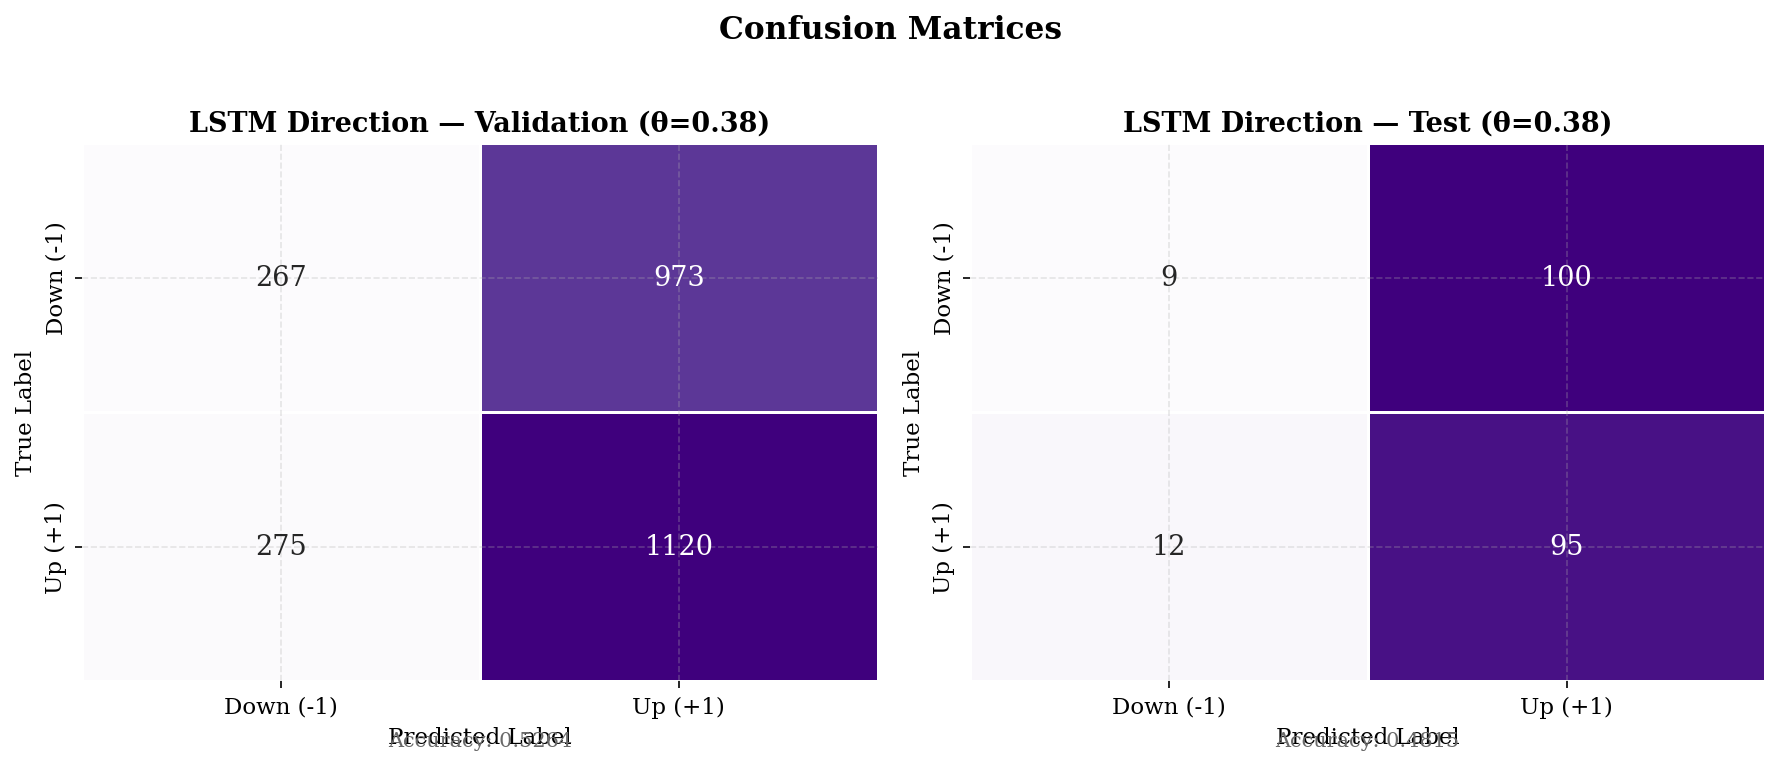

In [16]:
# ============================================================
# Confusion Matrix Heatmaps
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Down (-1)", "Up (+1)"]

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  pred_val_tuned,  "Validation"),
    (axes[1], y_test, pred_test_tuned, "Test"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, ax=ax, cbar=False, annot_kws={"size": 13})
    ax.set_title(f"LSTM Direction — {title} (θ={best_threshold:.2f})", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    acc = accuracy_score(y_true, y_pred)
    ax.text(0.5, -0.12, f"Accuracy: {acc:.4f}", transform=ax.transAxes,
            ha="center", fontsize=10, color="dimgray")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 17. Rolling Accuracy Over Time

60-day rolling accuracy on the test set, showing whether directional skill is consistent across market regimes.

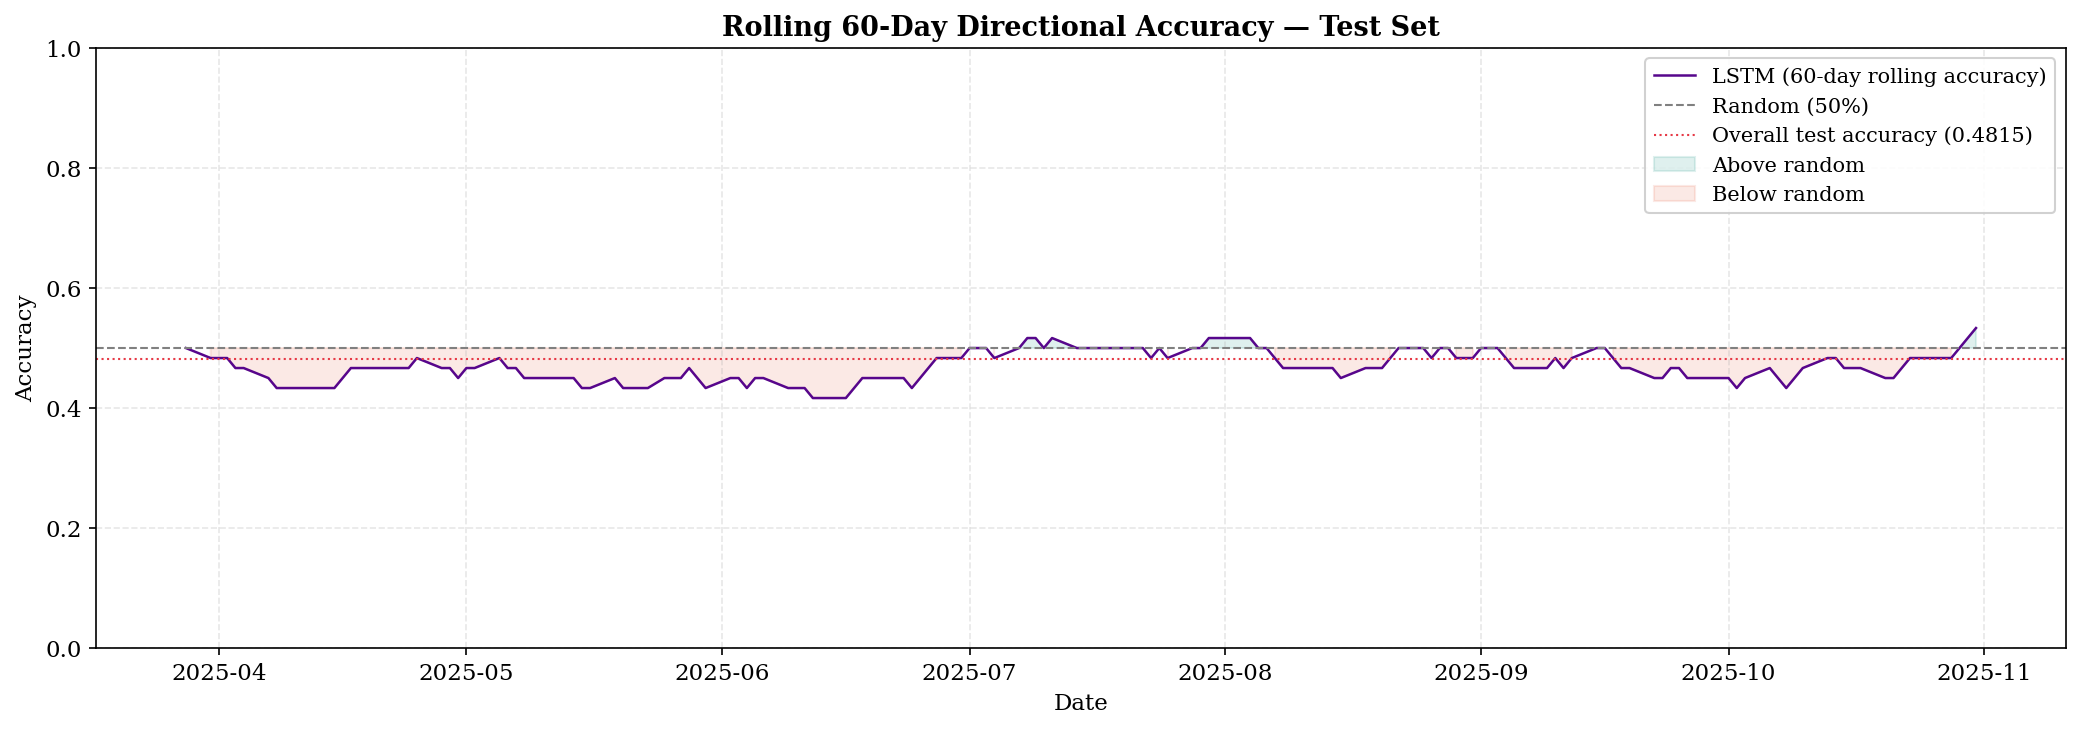

In [17]:
# ============================================================
# Rolling Accuracy Over Time (Test Set)
# ============================================================
roll_window = 60
correct  = (pred_test_tuned == y_test).astype(int)
roll_acc = pd.Series(correct, index=dates_test).rolling(roll_window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_acc.index, roll_acc.values, color=C['model'], lw=1.2,
        label=f"LSTM ({roll_window}-day rolling accuracy)")
ax.axhline(0.5, color="gray", lw=1, ls="--", label="Random (50%)")
ax.axhline(test_metrics_tuned["accuracy"], color=C['accent'], lw=1, ls=":",
           label=f"Overall test accuracy ({test_metrics_tuned['accuracy']:.4f})")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values >= 0.5, alpha=0.15, color=C['up'], label="Above random")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values < 0.5,  alpha=0.15, color=C['down'], label="Below random")
ax.set_title(f"Rolling {roll_window}-Day Directional Accuracy — Test Set", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Date")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 18. Predicted vs Actual Direction Distribution

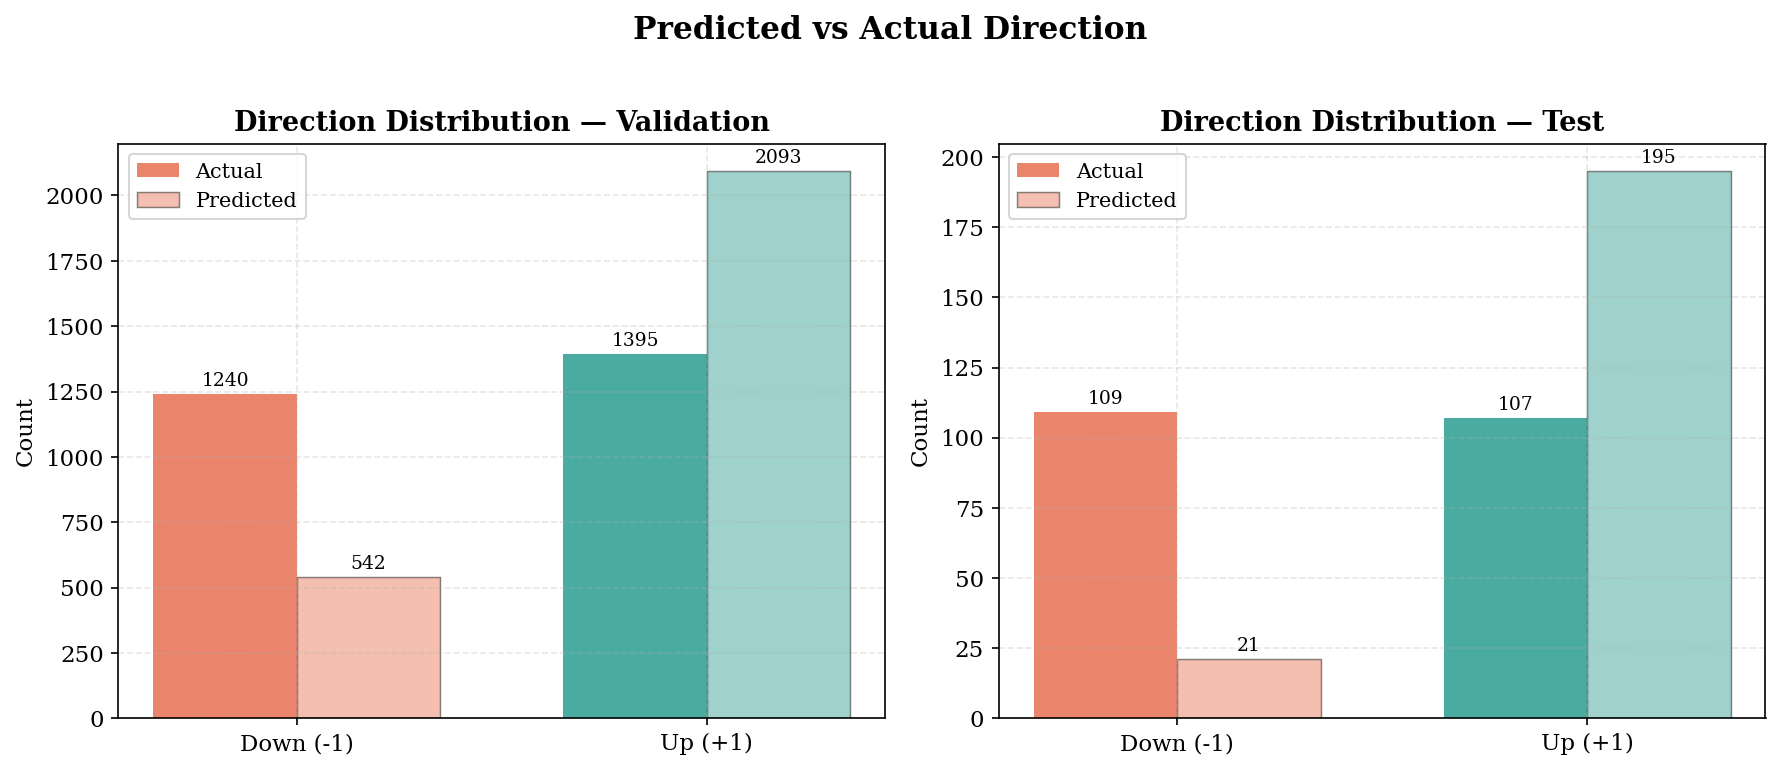

In [18]:
# ============================================================
# Direction Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  pred_val_tuned,  "Validation"),
    (axes[1], y_test, pred_test_tuned, "Test"),
]:
    cats = ["Down (-1)", "Up (+1)"]
    actual_counts = [(y_true == -1).sum(), (y_true == 1).sum()]
    pred_counts   = [(y_pred == -1).sum(), (y_pred == 1).sum()]
    x, w = np.arange(2), 0.35
    b1 = ax.bar(x - w/2, actual_counts, w, label="Actual",
                color=[C['down'], C['up']], alpha=0.85)
    b2 = ax.bar(x + w/2, pred_counts,   w, label="Predicted",
                color=[C['down'], C['up']], alpha=0.45,
                edgecolor='black', linewidth=0.7)
    for bar in list(b1) + list(b2):
        ax.annotate(f"{int(bar.get_height())}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
    ax.set_title(f"Direction Distribution — {title}", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_ylabel("Count"); ax.legend()

plt.suptitle("Predicted vs Actual Direction", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 19. ROC Curve — Train / Validation / Test

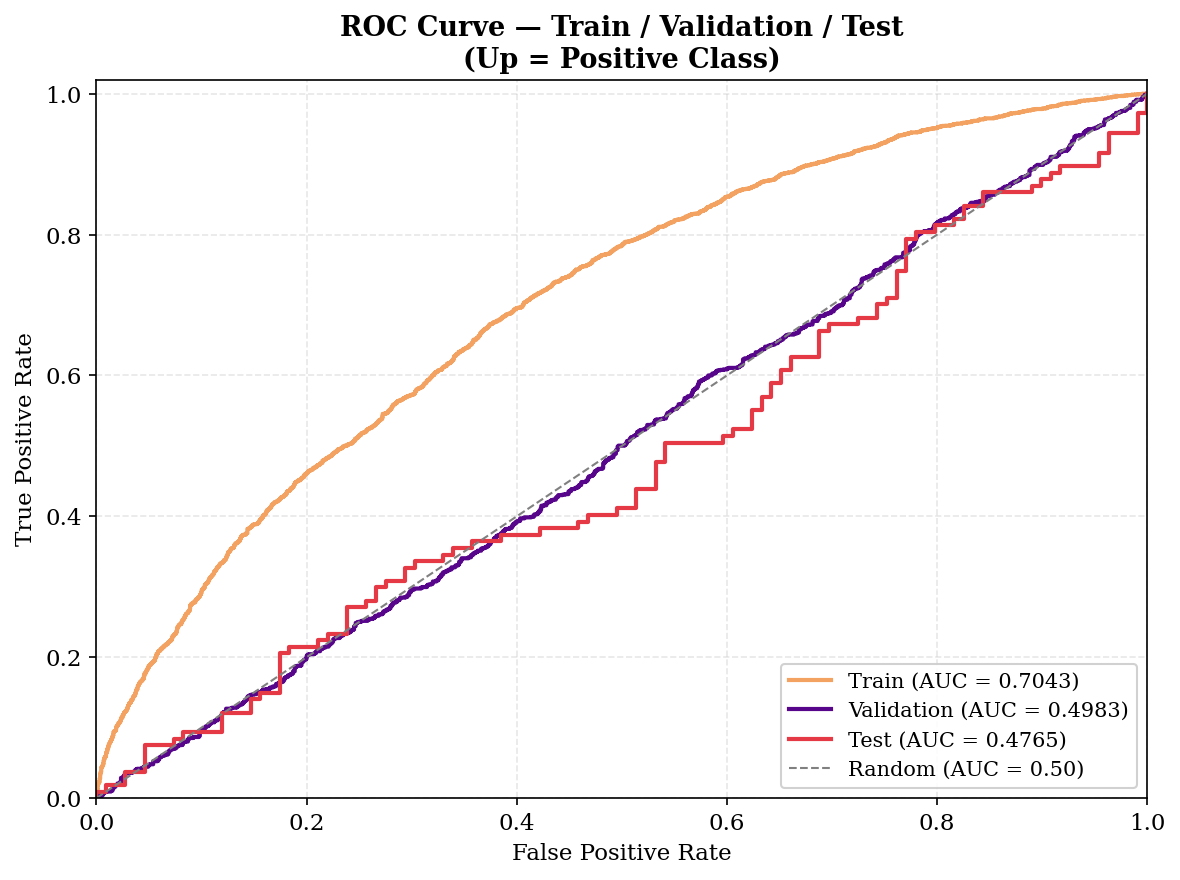

Split             AUC    Acc (θ=0.50)   Acc (tuned)
────────────────────────────────────────────────────
Train          0.7043          0.6487        0.6265
Validation     0.4983          0.5120        0.5264
Test           0.4765          0.5046        0.4815


In [19]:
# ============================================================
# ROC Curves
# ============================================================
from sklearn.metrics import roc_curve

prob_train_roc = model.predict_proba(X_train)

splits = [
    ("Train",      y_train, prob_train_roc, "#f4a261"),
    ("Validation", y_val,   prob_val,       C['model']),
    ("Test",       y_test,  prob_test,      C['accent']),
]

fig, ax = plt.subplots(figsize=(8, 6))
for label, y_true, y_prob, color in splits:
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {auc:.4f})")
ax.plot([0,1],[0,1], color="gray", lw=1, ls="--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — Train / Validation / Test\n(Up = Positive Class)", fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"{'Split':<12} {'AUC':>8}  {'Acc (θ=0.50)':>14}  {'Acc (tuned)':>12}")
print("─" * 52)
for label, y_true, y_prob, _ in splits:
    X_sp = X_train if label=="Train" else X_val if label=="Validation" else X_test
    acc_def  = accuracy_score(y_true, model.predict(X_sp))
    acc_tun  = accuracy_score(y_true, model.predict(X_sp, threshold=best_threshold))
    print(f"{label:<12} {roc_auc_score(y_true,y_prob):>8.4f}  {acc_def:>14.4f}  {acc_tun:>12.4f}")

## 20. CV Grid Search Balanced Accuracy

Each bar shows the mean 5-fold balanced accuracy for one hyperparameter configuration. Balanced accuracy (average of Down recall and Up recall) was used — rather than overall accuracy — so that the best configuration is the one that actually learns to distinguish both directions, not just the majority class.

Top 5 configs by CV balanced accuracy:
 hidden  layers  dropout     lr  bal_accuracy
     64       1      0.4 0.0010      0.521888
     32       2      0.4 0.0010      0.521408
     32       1      0.2 0.0010      0.521018
     64       2      0.2 0.0010      0.520059
     32       1      0.2 0.0005      0.519973


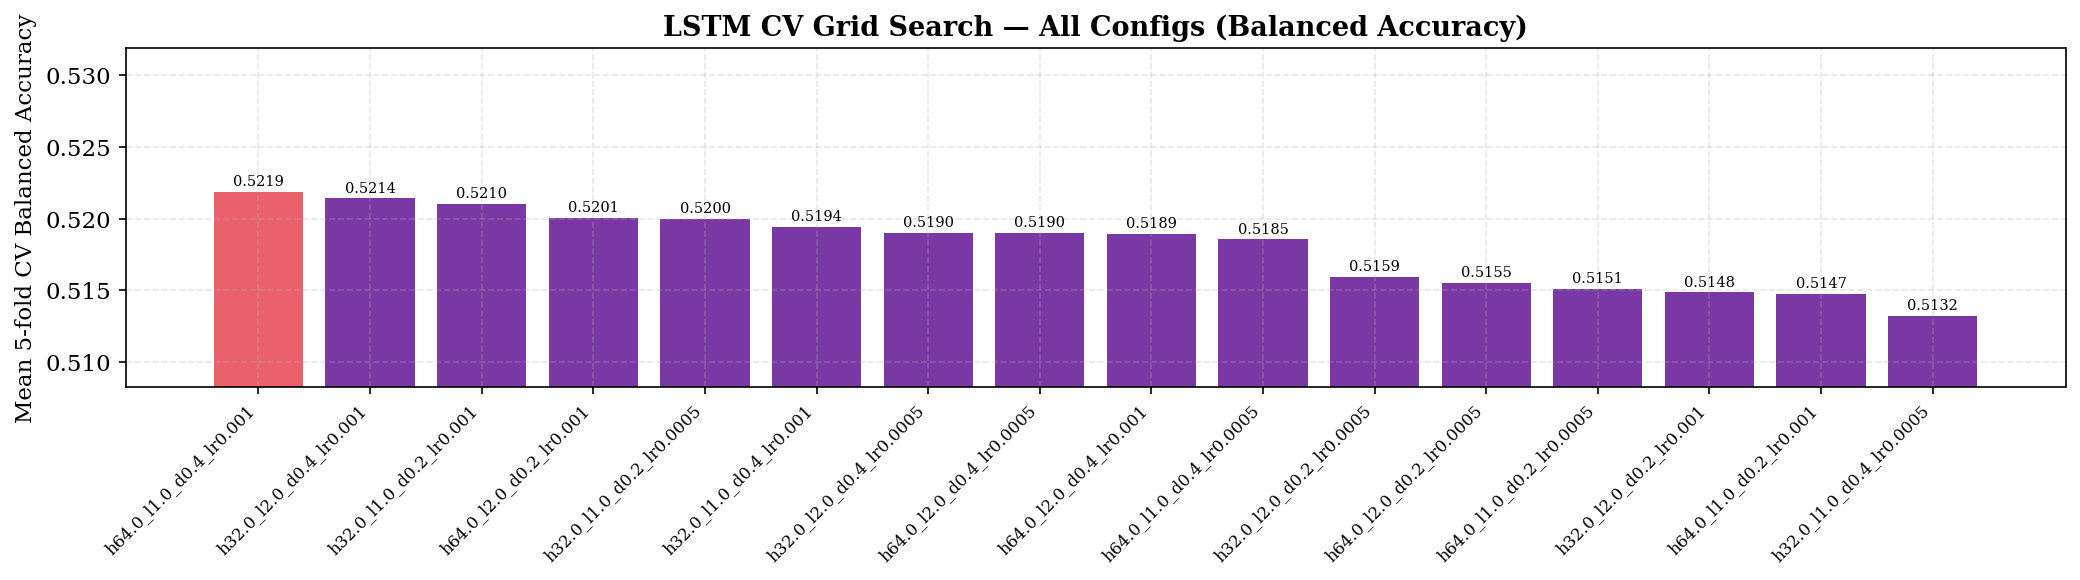

In [20]:
# ============================================================
# CV Grid Search Results
# ============================================================
cv_df = pd.DataFrame(model.cv_results_).sort_values("bal_accuracy", ascending=False)
print("Top 5 configs by CV balanced accuracy:")
print(cv_df.head(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 4))
labels_bar = [f"h{r['hidden']}_l{r['layers']}_d{r['dropout']}_lr{r['lr']}"
              for _, r in cv_df.iterrows()]
colors_bar = [C['accent'] if i == 0 else C['model'] for i in range(len(cv_df))]
bars = ax.bar(range(len(cv_df)), cv_df["bal_accuracy"], color=colors_bar, alpha=0.8)
ax.set_xticks(range(len(cv_df)))
ax.set_xticklabels(labels_bar, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean 5-fold CV Balanced Accuracy")
ax.set_title("LSTM CV Grid Search — All Configs (Balanced Accuracy)", fontweight="bold")
ax.set_ylim(cv_df["bal_accuracy"].min() - 0.005, cv_df["bal_accuracy"].max() + 0.01)
for bar in bars:
    ax.annotate(f"{bar.get_height():.4f}",
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,3), textcoords="offset points", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

## 21. Save Model

In [21]:
model.save("lstm_wti_direction.pkl")
print("Model saved to lstm_wti_direction.pkl")

Model saved to lstm_wti_direction.pkl
